# Trabalho prático 1
Implementação e comparação de um algoritmo KNN usando como base a base de dados Iris

## Introdução

Este notebook tem como objetivo implementar e comparar dois classificadores K-Nearest Neighbors (KNN): uma versão desenvolvida manualmente, sem utilizar a biblioteca pronta, e outra versão usando o algoritmo já implementado pela biblioteca scikit-learn.

A base de dados utilizada será a base Iris, amplamente empregada em tarefas de classificação, contendo medidas de largura e comprimento de pétalas e sépalas de três espécies de flores: Setosa, Versicolor e Virginica.

## Objetivo da atividade

- Implementar o algoritmo KNN do zero em Python;
- Avaliar o desempenho para os valores de k = 1, 3, 5 e 7;
- Calcular a matriz de confusão e as métricas de precisão, revocação e acurácia;
- Repetir o processo com a implementação do scikit-learn;
- Comparar os resultados obtidos e discutir o desempenho das duas abordagens.

## Integrantes

- Anderson Fernandes Barbosa
- João Pedro Brites

## Descrição do trabalho

A atividade simula a aplicação de um classificador supervisionado em dados reais, permitindo analisar como diferentes valores de vizinhos influenciam a classificação. Além disso, a comparação entre uma implementação manual e uma implementação de biblioteca ajuda a compreender melhor os princípios do algoritmo e o comportamento prático em termos de desempenho e acurácia.



K = 1
Acurácia: 0.9333
Precisão (macro): 0.9444
Revocação (macro): 0.9333
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]


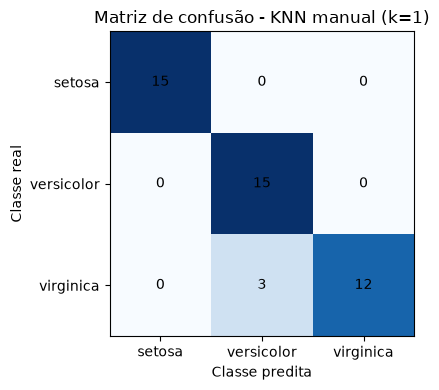


K = 3
Acurácia: 0.9556
Precisão (macro): 0.9608
Revocação (macro): 0.9556
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


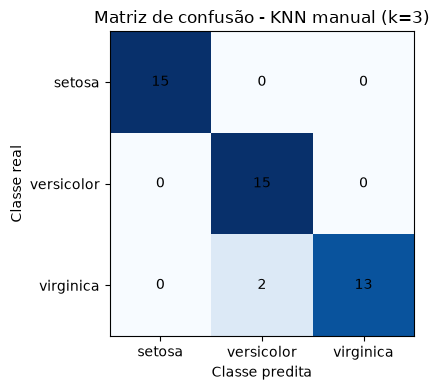


K = 5
Acurácia: 0.9778
Precisão (macro): 0.9792
Revocação (macro): 0.9778
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


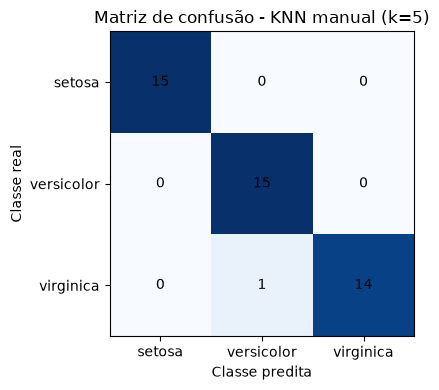


K = 7
Acurácia: 0.9556
Precisão (macro): 0.9608
Revocação (macro): 0.9556
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


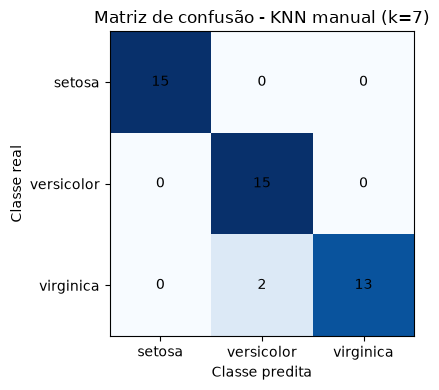

In [3]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

iris = load_iris(as_frame=True)
X = iris.data.to_numpy()
y = iris.target.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))


def knn_manual_predict(X_train, y_train, sample, k):
    distances = []
    for i, x_train in enumerate(X_train):
        dist = euclidean_distance(x_train, sample)
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda item: item[0])
    neighbors = [label for _, label in distances[:k]]
    labels, counts = np.unique(neighbors, return_counts=True)
    return labels[np.argmax(counts)]


for k in [1, 3, 5, 7]:
    predictions = []
    for sample in X_test:
        predictions.append(knn_manual_predict(X_train, y_train, sample, k))
    predictions = np.array(predictions)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='macro', zero_division=0)
    recall = recall_score(y_test, predictions, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, predictions, labels=[0, 1, 2])

    print(f"\nK = {k}")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão (macro): {precision:.4f}")
    print(f"Revocação (macro): {recall:.4f}")
    print("Matriz de confusão:")
    print(cm)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Matriz de confusão - KNN manual (k={k})')
    plt.xticks([0, 1, 2], iris.target_names)
    plt.yticks([0, 1, 2], iris.target_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

    plt.xlabel('Classe predita')
    plt.ylabel('Classe real')
    plt.tight_layout()
    plt.show()


## Bloco 1: Implementação do classificador KNN manual

Neste bloco será carregada a base Iris e será feita a preparação dos dados para o treinamento e teste do classificador.

A estrutura da implementação manual inclui:
- carregamento da base de dados;
- separação entre atributos e rótulos;
- normalização ou manutenção dos dados em escala adequada;
- cálculo da distância entre os pontos;
- escolha dos k vizinhos mais próximos;
- votação por maioria para a classe final;
- avaliação da classificação para diferentes valores de k.

A ideia é demonstrar a lógica do algoritmo sem depender de uma implementação pronta da biblioteca.


## Bloco 2: Implementação com scikit-learn e análise dos resultados

Neste segundo bloco será utilizada a implementação do algoritmo KNN disponível na biblioteca scikit-learn para comparar diretamente os resultados com a solução manual.

Serão executados os passos a seguir:
- criação do modelo KNN da biblioteca;
- treinamento com os dados de treinamento;
- predição sobre os dados de teste;
- cálculo da matriz de confusão;
- cálculo de precisão, revocação e acurácia;
- comparação dos resultados obtidos com a implementação manual.

Também será realizada uma análise visual dos indicadores de desempenho, destacando as diferenças entre as duas abordagens.

## Observações sobre a comparação

A comparação entre os dois classificadores permite avaliar:
- a robustez da implementação manual;
- a precisão da solução baseada em biblioteca;
- a influência do parâmetro k no desempenho;
- eventuais diferenças em tempo de execução e qualidade da classificação.

Essa análise é essencial para concluir qual abordagem apresenta melhor desempenho para a base Iris.



K = 1
Tempo de treinamento + predição: 0.003872 s
Acurácia: 0.9333
Precisão (macro): 0.9444
Revocação (macro): 0.9333
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  3 12]]


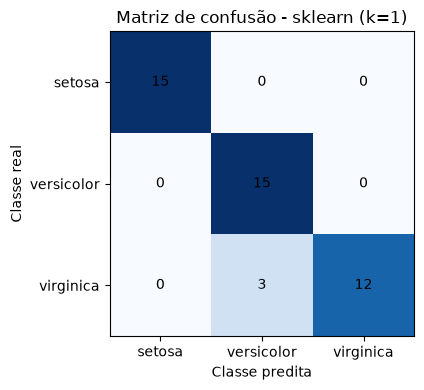


K = 3
Tempo de treinamento + predição: 0.004277 s
Acurácia: 0.9556
Precisão (macro): 0.9608
Revocação (macro): 0.9556
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


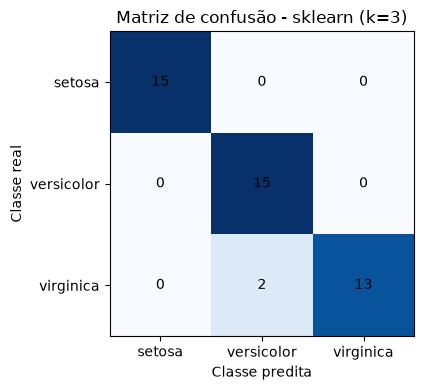


K = 5
Tempo de treinamento + predição: 0.003478 s
Acurácia: 0.9778
Precisão (macro): 0.9792
Revocação (macro): 0.9778
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


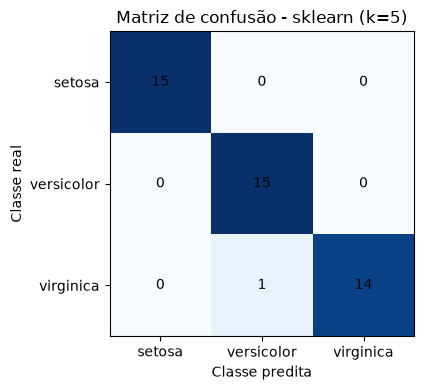


K = 7
Tempo de treinamento + predição: 0.003882 s
Acurácia: 0.9556
Precisão (macro): 0.9608
Revocação (macro): 0.9556
Matriz de confusão:
[[15  0  0]
 [ 0 15  0]
 [ 0  2 13]]


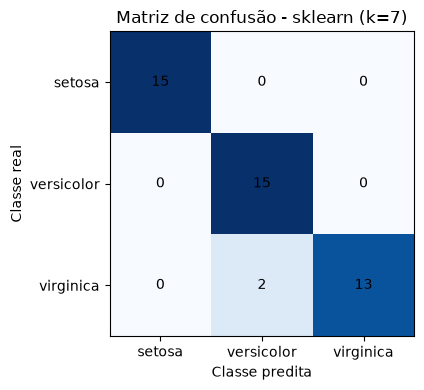

In [4]:
from sklearn.neighbors import KNeighborsClassifier
import time

for k in [1, 3, 5, 7]:
    model = KNeighborsClassifier(n_neighbors=k)
    start_time = time.perf_counter()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    elapsed_time = time.perf_counter() - start_time

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='macro', zero_division=0)
    recall = recall_score(y_test, predictions, average='macro', zero_division=0)
    cm = confusion_matrix(y_test, predictions, labels=[0, 1, 2])

    print(f"\nK = {k}")
    print(f"Tempo de treinamento + predição: {elapsed_time:.6f} s")
    print(f"Acurácia: {accuracy:.4f}")
    print(f"Precisão (macro): {precision:.4f}")
    print(f"Revocação (macro): {recall:.4f}")
    print("Matriz de confusão:")
    print(cm)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap='Blues')
    plt.title(f'Matriz de confusão - sklearn (k={k})')
    plt.xticks([0, 1, 2], iris.target_names)
    plt.yticks([0, 1, 2], iris.target_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

    plt.xlabel('Classe predita')
    plt.ylabel('Classe real')
    plt.tight_layout()
    plt.show()


## Conclusão

A partir da comparação entre a implementação manual e a implementação do KNN com a biblioteca scikit-learn, é possível observar como o algoritmo funciona na prática e como pequenas mudanças no valor de k podem influenciar os resultados.

Em geral, a implementação manual demonstra o funcionamento interno do classificador e ajuda a fixar os conceitos teóricos aprendidos em aula, enquanto a versão com biblioteca representa uma solução mais otimizada e prática para uso em projetos reais.

Por meio da análise das métricas de acurácia, precisão e revocação, além da matriz de confusão, é possível concluir que o KNN é uma técnica simples, eficiente e bastante útil para classificação de dados tabulares como a base Iris.

Este notebook foi estruturado para demonstrar o desenvolvimento completo da atividade, desde a ideia do algoritmo até a comparação dos resultados finais.
